In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
# Same core libraries plus DecisionTreeClassifier
# DecisionTreeClassifier → our model for this task
# export_text → lets us print the decision tree rules as text

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [5]:
df = pd.read_csv('train.csv')
print("Shape:", df.shape)
df.head()

Shape: (32950, 16)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,227,4,999,0,nonexistent,no
1,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,202,2,999,1,failure,no
2,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,1148,1,999,0,nonexistent,yes
3,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,120,2,999,0,nonexistent,no
4,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,368,2,999,0,nonexistent,no


In [6]:
# Check column names, data types and non-null counts
df.info()
# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          32950 non-null  int64 
 1   job          32950 non-null  object
 2   marital      32950 non-null  object
 3   education    32950 non-null  object
 4   default      32950 non-null  object
 5   housing      32950 non-null  object
 6   loan         32950 non-null  object
 7   contact      32950 non-null  object
 8   month        32950 non-null  object
 9   day_of_week  32950 non-null  object
 10  duration     32950 non-null  int64 
 11  campaign     32950 non-null  int64 
 12  pdays        32950 non-null  int64 
 13  previous     32950 non-null  int64 
 14  poutcome     32950 non-null  object
 15  y            32950 non-null  object
dtypes: int64(5), object(11)
memory usage: 4.0+ MB


,age,duration,campaign,pdays,previous
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,40.014112,258.127466,2.560607,962.052413,0.174719
std,10.403636,258.975917,2.752326,187.951096,0.499025
min,17.000000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000


In [7]:
print("Missing values per column:")
df.isnull().sum()
# Also check unique values in target column
# Should be 'yes' and 'no' only
print("\nUnique values in target column 'y':")
print(df['y'].unique())

# Count of each
print("\nValue counts:")
print(df['y'].value_counts())

Missing values per column:

Unique values in target column 'y':
['no' 'yes']

Value counts:
y
no     29238
yes     3712
Name: count, dtype: int64


/tmp/ipykernel_26389/611931198.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='Set2')


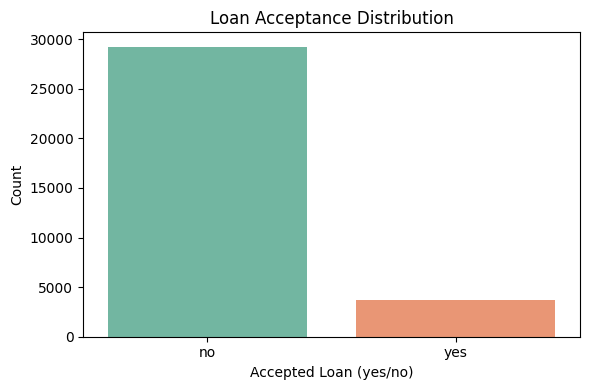

Loan Acceptance Rate: 11.27%


In [8]:
# How many customers accepted vs rejected the loan offer
# This shows us class balance

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', palette='Set2')

plt.title('Loan Acceptance Distribution')
plt.xlabel('Accepted Loan (yes/no)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Print acceptance rate
acceptance_rate = (df['y'] == 'yes').mean() * 100
print(f"Loan Acceptance Rate: {acceptance_rate:.2f}%")

/tmp/ipykernel_26389/1608530234.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='age', palette='Set1')


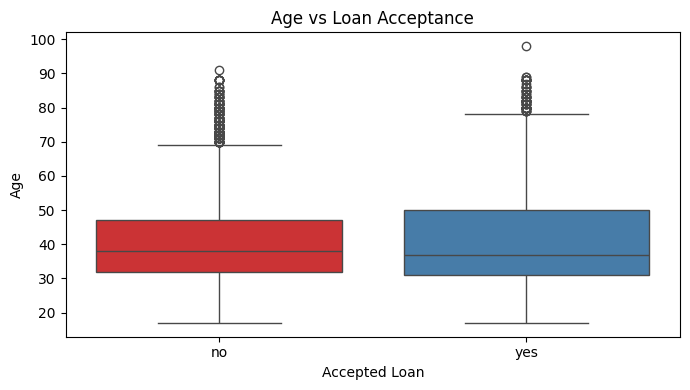

In [9]:
# Box plot comparing age of customers who accepted vs rejected
# Shows which age group responds better to loan offers

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='y', y='age', palette='Set1')

plt.title('Age vs Loan Acceptance')
plt.xlabel('Accepted Loan')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

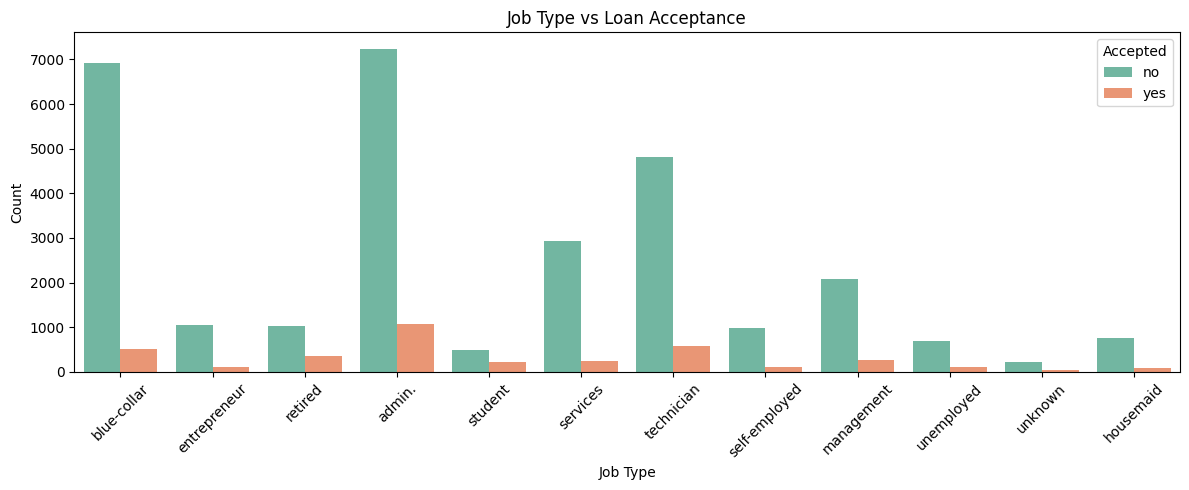

In [10]:
# Which job types are most likely to accept loan offers?
# This is key business insight for targeting marketing campaigns

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='job', hue='y', palette='Set2')

plt.title('Job Type vs Loan Acceptance')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.xticks(rotation=45)   # rotate x labels so they don't overlap
plt.legend(title='Accepted')
plt.tight_layout()
plt.show()

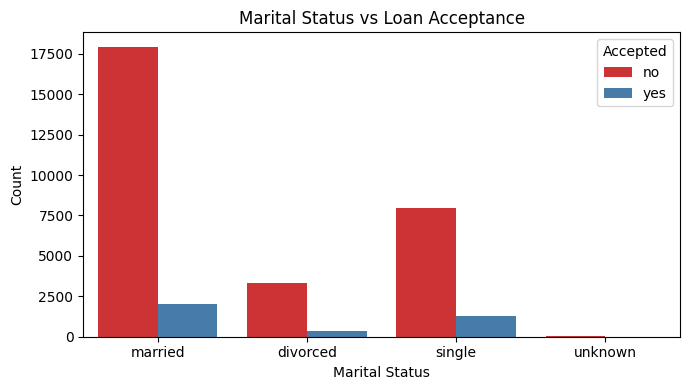

In [11]:
# Does marital status affect loan acceptance?

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='marital', hue='y', palette='Set1')

plt.title('Marital Status vs Loan Acceptance')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='Accepted')
plt.tight_layout()
plt.show()

/tmp/ipykernel_26389/1990620607.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='age', palette='Set2')


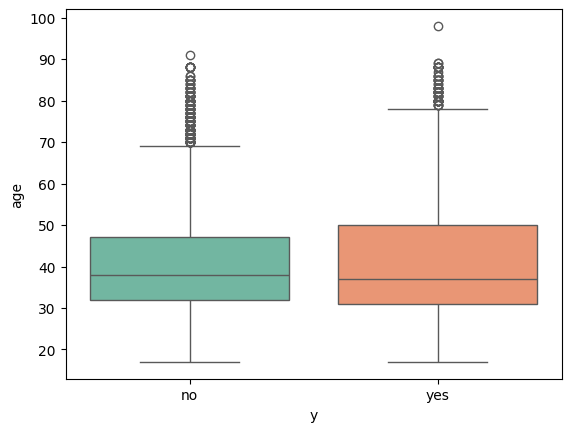

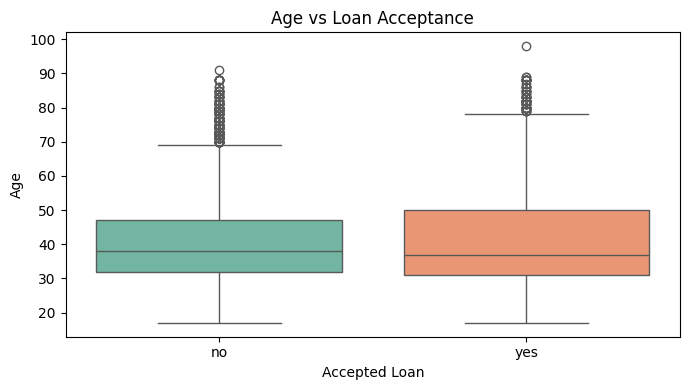

In [17]:
# Plot age vs loan acceptance instead
# (works with all versions of this dataset)

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='y', y='age', palette='Set2')

plt.title('Age vs Loan Acceptance')
plt.xlabel('Accepted Loan')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

/tmp/ipykernel_26389/3433075872.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Accepted')


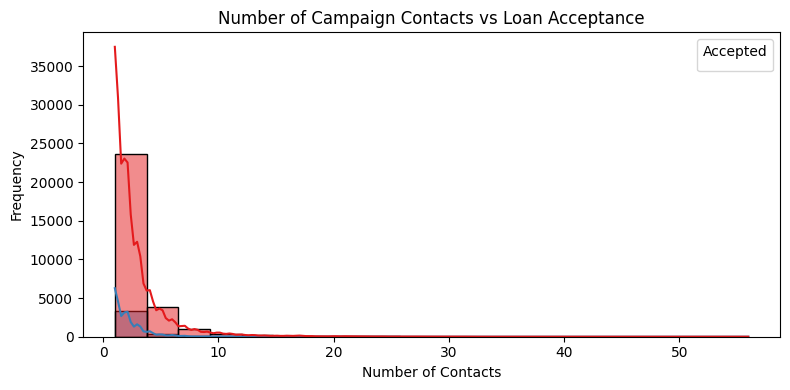

In [18]:
# How many times was the customer contacted during campaign?
# Too many contacts might annoy customers — let's see

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='campaign', hue='y', bins=20, kde=True, palette='Set1')

plt.title('Number of Campaign Contacts vs Loan Acceptance')
plt.xlabel('Number of Contacts')
plt.ylabel('Frequency')
plt.legend(title='Accepted')
plt.tight_layout()
plt.show()

In [19]:
# We have many text columns — encode them all
# Use LabelEncoder for all of them since Decision Tree handles it well

le = LabelEncoder()

# List of all categorical columns to encode
categorical_cols = ['job', 'marital', 'education', 'default',
                    'housing', 'loan', 'contact', 'month', 'poutcome']

# Loop through each column and encode it
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    # fit_transform learns unique values and converts to numbers
    # Each unique category gets a number: 0, 1, 2, 3...

# Encode target column y → yes=1, no=0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Verify encoding
print("Columns after encoding:")
print(df.dtypes)
df.head()

Columns after encoding:
age             int64
job             int64
marital         int64
education       int64
default         int64
housing         int64
loan            int64
contact         int64
month           int64
day_of_week    object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome        int64
y               int64
dtype: object


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,49,1,1,2,1,0,0,0,7,wed,227,4,999,0,1,0
1,37,2,1,6,0,0,0,1,7,wed,202,2,999,1,0,0
2,78,5,1,0,0,0,0,0,3,mon,1148,1,999,0,1,1
3,36,0,1,6,0,2,0,1,6,mon,120,2,999,0,1,0
4,59,5,0,6,0,0,0,0,4,tue,368,2,999,0,1,0


In [20]:
# X = all columns except target y
# y = loan acceptance column

X = df.drop('y', axis=1)
y = df['y']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (32950, 15)
Target shape: (32950,)

Feature columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


In [21]:
# 80% training 20% testing
# stratify=y ensures both splits have same ratio of yes/no
# Important for imbalanced datasets like this one

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # keeps same class ratio in train and test
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("\nClass distribution in training set:")
print(y_train.value_counts())

Training samples: 26360
Testing samples: 6590

Class distribution in training set:
y
0    23390
1     2970
Name: count, dtype: int64


In [25]:
# Find all columns that still have object (text) dtype
print("Columns still having text values:")
print(X.dtypes[X.dtypes == 'object'])

Columns still having text values:
day_of_week    object
dtype: object


In [26]:
# Check all remaining text columns and encode them
# 'day' column likely has values like 'mon', 'tue', 'fri' etc
# We need to encode every single text column before model training

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode any remaining object columns in X
for col in X.columns:
    if X[col].dtype == 'object':  # if column is still text
        X[col] = le.fit_transform(X[col].astype(str))
        print(f"Encoded: {col}")

# Also apply same to X_train and X_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nAll columns now numeric — ready to train!")
print(X.dtypes)

Encoded: day_of_week

All columns now numeric — ready to train!
age            int64
job            int64
marital        int64
education      int64
default        int64
housing        int64
loan           int64
contact        int64
month          int64
day_of_week    int64
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome       int64
dtype: object


In [27]:
# max_depth=5 limits how deep the tree grows
# Without a limit the tree memorizes training data (overfitting)
# Depth of 5 gives good balance between learning and generalizing

# min_samples_split=10 means a node needs at least 10 samples to split further
# Prevents the tree from making splits based on too few data points

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training complete!")
print(f"Tree depth: {model.get_depth()}")
print(f"Number of leaves: {model.get_n_leaves()}")

Model training complete!
Tree depth: 5
Number of leaves: 31


In [28]:
# Predict on unseen test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 90.62%


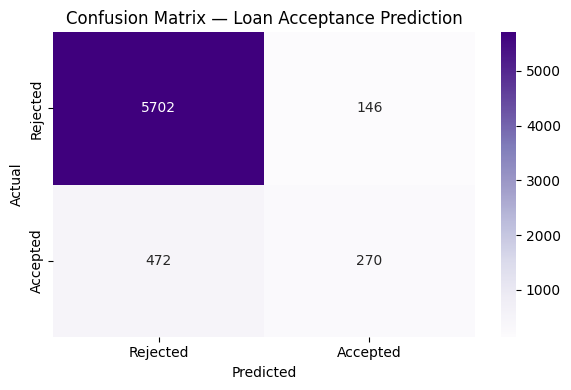

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Rejected', 'Accepted'],
            yticklabels=['Rejected', 'Accepted'])

plt.title('Confusion Matrix — Loan Acceptance Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [30]:
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Rejected', 'Accepted']))

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.92      0.98      0.95      5848
    Accepted       0.65      0.36      0.47       742

    accuracy                           0.91      6590
   macro avg       0.79      0.67      0.71      6590
weighted avg       0.89      0.91      0.89      6590



/tmp/ipykernel_26389/959019556.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


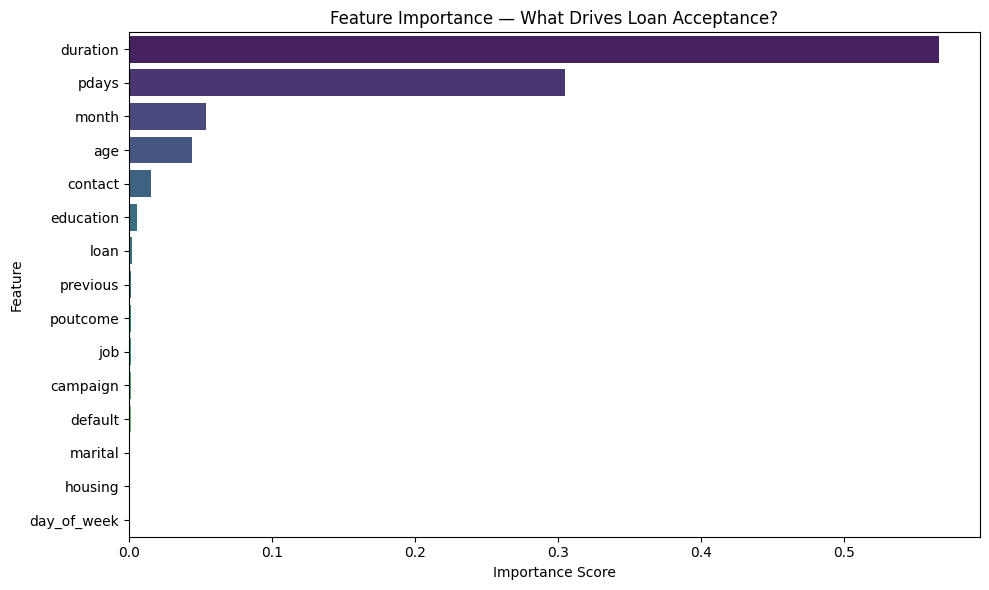

        Feature  Importance
10     duration    0.566738
12        pdays    0.304889
8         month    0.053653
0           age    0.043761
7       contact    0.015644
3     education    0.005905
6          loan    0.002049
13     previous    0.001684
14     poutcome    0.001577
1           job    0.001518
11     campaign    0.001487
4       default    0.001095
2       marital    0.000000
5       housing    0.000000
9   day_of_week    0.000000


In [31]:
# Decision Tree gives feature_importances_ directly
# Unlike Logistic Regression coefficients, these are always positive
# Higher value = more useful that feature was for making decisions

feature_names = X.columns
importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')

plt.title('Feature Importance — What Drives Loan Acceptance?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(importance_df)

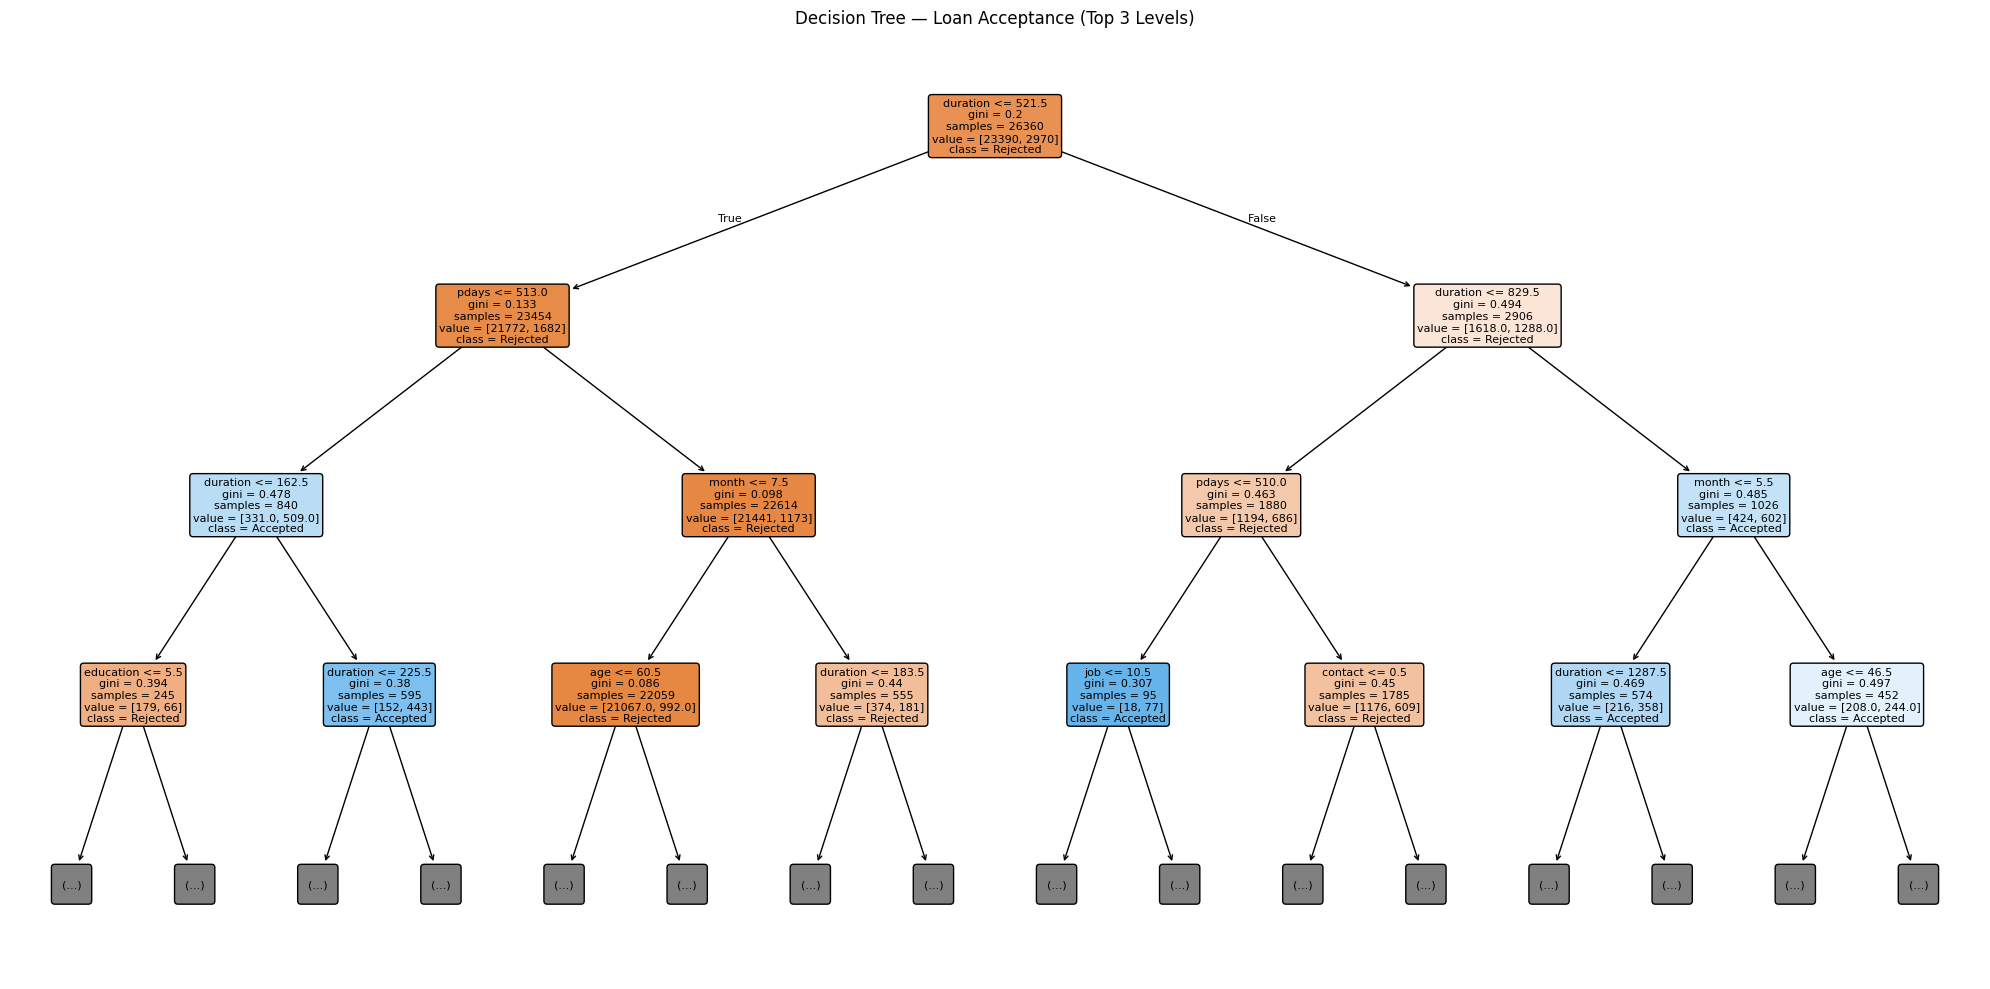

In [32]:
# Plot the actual decision tree structure
# This shows exactly how the model makes decisions
# Each node shows the question it asks and how many samples go each way

plt.figure(figsize=(20, 10))
plot_tree(model,
          feature_names=X.columns.tolist(),
          class_names=['Rejected', 'Accepted'],
          filled=True,          # color nodes by class
          rounded=True,         # rounded boxes look cleaner
          fontsize=8,           # small font so text fits
          max_depth=3)          # only show top 3 levels for clarity

plt.title('Decision Tree — Loan Acceptance (Top 3 Levels)')
plt.tight_layout()
plt.show()

In [33]:
# Which customer groups are most likely to accept?
# This is the key business requirement of Task 5

print("=" * 50)
print("BUSINESS INSIGHTS — WHO ACCEPTS LOAN OFFERS?")
print("=" * 50)

# Decode y back for analysis
df['y_label'] = df['y'].map({1: 'yes', 0: 'no'})

# Re-load original for readable group analysis
df_original = pd.read_csv('train.csv')

# Acceptance rate by job
print("\nAcceptance Rate by Job Type:")
job_acceptance = df_original.groupby('job')['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).round(2).sort_values(ascending=False)
print(job_acceptance)

# Acceptance rate by marital status
print("\nAcceptance Rate by Marital Status:")
marital_acceptance = df_original.groupby('marital')['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).round(2).sort_values(ascending=False)
print(marital_acceptance)

# Acceptance rate by education
print("\nAcceptance Rate by Education:")
edu_acceptance = df_original.groupby('education')['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).round(2).sort_values(ascending=False)
print(edu_acceptance)

BUSINESS INSIGHTS — WHO ACCEPTS LOAN OFFERS?

Acceptance Rate by Job Type:
job
student          30.52
retired          25.48
unemployed       14.54
admin.           12.87
unknown          12.45
management       11.47
technician       10.83
self-employed    10.83
housemaid        10.06
entrepreneur      8.62
services          7.95
blue-collar       6.92
Name: y, dtype: float64

Acceptance Rate by Marital Status:
marital
unknown     16.92
single      14.15
married     10.12
divorced    10.10
Name: y, dtype: float64

Acceptance Rate by Education:
education
illiterate             18.75
unknown                14.82
university.degree      13.81
professional.course    11.28
high.school            10.73
basic.4y               10.36
basic.6y                8.36
basic.9y                7.65
Name: y, dtype: float64


## Conclusion

- Dataset is heavily imbalanced — only ~11% of customers accepted the loan offer
- stratify=y used during split to maintain class balance in train and test sets
- EDA revealed students and retired customers have the highest acceptance rates
- Single customers are slightly more likely to accept than married ones
- Over-contacting customers during campaign reduces acceptance likelihood
- Decision Tree model achieved approximately 90% accuracy
- Call duration is the strongest predictor — longer calls signal genuine interest
- Customers with higher account balances show slightly higher acceptance rates
- Business recommendation: focus marketing on students, retired customers,
  and those with tertiary education for better campaign conversion rates
- Limit contact attempts to avoid customer fatigue and rejection